# Physics-Informed Neural Networks (PINNs)  
## Aplicación a la Caída Libre Bajo Gravedad

Este cuaderno implementa una **Physics-Informed Neural Network (PINN)** para modelar el movimiento vertical de un objeto bajo la influencia de la gravedad constante, utilizando datos sintéticos con ruido.

---

### **1. Enunciado del problema**

Se estudia el movimiento vertical de un objeto sometido únicamente a la fuerza de gravedad constante. La ecuación diferencial que describe este fenómeno es:

$$
\frac{d^2h}{dt^2} = -g \quad (1)
$$

donde:
- \( h(t) \) es la altura del objeto en función del tiempo \( t \)
- \( g > 0 \) es la aceleración gravitatoria (constante)

### **2. Condiciones iniciales**

$$
h(0) = h_0, \quad v(0) = v_0 \quad (2)
$$

donde:
- $h_0$ es la altura inicial del objeto
- $v_0$ es la velocidad inicial

---

### **3. Relaciones cinemáticas**

$$
\begin{aligned}
h(t) & : \text{posición (altura)} \\
v(t) & = \frac{dh}{dt} \quad (\text{velocidad}) \\
a(t) & = \frac{dv}{dt} = \frac{d^2h}{dt^2} \quad (\text{aceleración})
\end{aligned} \quad (5)
$$

### **4. Deducción de la solución analítica**

#### 4.1. Paso 1: Integración para obtener la velocidad

Partiendo de la ecuación (1):

$$
\frac{dv}{dt} = -g \quad (6)
$$

Separando variables e integrando:

$$
\int dv = -g \int dt \quad (7)
$$

$$
v(t) = -g t + C_1 \quad (8)
$$

Aplicando la condición inicial $v(0) = v_0$:

$$
v(0) = -g \cdot 0 + C_1 = v_0 \Rightarrow C_1 = v_0 \quad (9)
$$

Obtenemos la expresión para la velocidad:

$$
\boxed{v(t) = v_0 - g t} \quad (10)
$$

---

#### 4.2. Paso 2: Integración para obtener la altura

De la ecuación (10):

$$
\frac{dh}{dt} = v_0 - g t \quad (11)
$$

Integrando nuevamente:

$$
\int dh = \int (v_0 - g t) dt \quad (12)
$$

$$
h(t) = v_0 t - \frac{g}{2} t^2 + C_2 \quad (13)
$$

Aplicando la condición inicial $h(0) = h_0$:

$$
h(0) = v_0 \cdot 0 - \frac{g}{2} \cdot 0^2 + C_2 = h_0 \Rightarrow C_2 = h_0 \quad (14)
$$

Obtenemos la solución final para la altura:

$$
\boxed{h(t) = h_0 + v_0 t - \frac{1}{2} g t^2} \quad (15)
$$

### **5. Sistema completo de ecuaciones**

La solución completa del problema de caída libre queda descrita por:

$$
\begin{cases}
h(t) = h_0 + v_0 t - \frac{1}{2} g t^2 \\
v(t) = v_0 - g t \\
a(t) = -g
\end{cases} \quad (16)
$$

---

### **6. Caso numérico específico**

Para el caso utilizado en la implementación de la PINN:

$$
g = 9.8 \, \mathrm{m/s^2}, \quad h_0 = 1.0 \, \mathrm{m}, \quad v_0 = 10.0 \, \mathrm{m/s} \quad (17)
$$

La ecuación (15) se particulariza como:

$$
\boxed{h(t) = 1.0 + 10.0 t - 4.9 t^2} \quad (18)
$$

### **8. Verificación de la solución**

Sustituyendo la solución (15) en la EDO original (1):

$$
\begin{aligned}
\frac{dh}{dt} &= \frac{d}{dt} \left( h_0 + v_0 t - \frac{1}{2} g t^2 \right) = v_0 - g t \\
\frac{d^2h}{dt^2} &= \frac{d}{dt} (v_0 - g t) = -g
\end{aligned} \quad (21)
$$

Se verifica que efectivamente satisface la ecuación diferencial original.

---

### **9. Aplicación en la generación de datos sintéticos**

En el contexto del entrenamiento de la **Physics-Informed Neural Network (PINN)**, la solución analítica se utiliza para generar datos sintéticos con ruido:

$$
h_{\mathrm{data}}(t) = h_0 + v_0 t - \frac{1}{2} g t^2 + \epsilon \quad (23)
$$

donde $\epsilon \sim \mathcal{N}(0, \sigma)$ es ruido gaussiano con desviación estándar $\sigma = 0.7$, simulando errores de medición experimentales.

#### 9.1. Ventajas de esta aproximación

1. Permite generar datos de entrenamiento controlados y etiquetados.
2. Facilita la evaluación cuantitativa del rendimiento de la PINN.
3. Proporciona un *ground truth* para validar la precisión de las predicciones.
4. Permite estudiar el efecto del ruido en la capacidad de aprendizaje de la red.

### **10. Conclusiones**

La solución analítica presentada:

1. Proporciona una descripción exacta del movimiento de caída libre bajo gravedad constante.
2. Sirve como referencia fundamental para el desarrollo y validación de métodos numéricos.
3. En el contexto de PINNs, actúa como el *ground truth* necesario para:
   - Generar datos sintéticos de entrenamiento.
   - Evaluar la precisión de las predicciones.
   - Verificar que la red neuronal aprenda correctamente la física subyacente.

Esta formulación matemática constituye la base sobre la cual se implementa la **Physics-Informed Neural Network**, permitiendo combinar el conocimiento físico (ecuaciones diferenciales) con técnicas de aprendizaje automático para resolver problemas de ingeniería y física.

In [ ]:
  # ============================================
#  IMPORTACIÓN DE LIBRERÍAS
# ============================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


# 1. Generación de datos sintéticos

In [ ]:
# ============================================
# 1. GENERAR DATOS SINTÉTICOS
# ============================================

# Parámetros físicos reales del sistema
g = 9.8        # Aceleración de la gravedad [m/s^2]
h0 = 1.0       # Altura inicial [m]
v0 = 10.0       # Velocidad inicial hacia arriba [m/s]

# Solución analítica de la EDO:
# h(t) = h0 + v0 t - (1/2) g t^2
def true_solution(t):
    return h0 + v0*t - 0.5*g*(t**2)

# Intervalo de tiempo y número de muestras experimentales
t_min, t_max = 0.0, 2.0
N_data = 10
t_data = np.linspace(t_min, t_max, N_data)

# Generamos datos sintéticos con ruido tipo "muestra experimental"
np.random.seed(0)
noise_level = 0.7
h_data_exact = true_solution(t_data)
h_data_noisy = h_data_exact + noise_level*np.random.randn(N_data)

# Convertimos datos a tensores de PyTorch
t_data_tensor = torch.tensor(t_data, dtype=torch.float32).view(-1, 1)
h_data_tensor = torch.tensor(h_data_noisy, dtype=torch.float32).view(-1, 1)


# 2. Definición del modelo neuronal

In [ ]:
# ============================================
# 2. DEFINIR LA RED NEURONAL PARA h(t)
# ============================================

class PINN(nn.Module):
    def __init__(self, n_hidden=20):
        super(PINN, self).__init__()

        # Pequeña red neuronal tipo MLP de 3 capas ocultas
        # Activación Tanh: suave y derivable (ideal para AD)
        self.net = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 1)
        )

    def forward(self, t):
        """
        Propagación hacia adelante: recibe t y produce h(t).
        """
        return self.net(t)

# Instanciamos el modelo
model = PINN(n_hidden=20)


# 3. Rutina para obtener derivadas automáticas (“AD”)

In [ ]:
# ============================================
# 3. UTILIDAD PARA DERIVADAS AUTOMÁTICAS
# ============================================

def derivative(y, x):
    """
    Calcula dy/dx usando PyTorch Autograd.
    Es esencial para obtener derivadas dh/dt dentro de la PINN.
    """
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]


# 4. Definición de las pérdidas

In [ ]:
# ============================================
# 4. DEFINIR PÉRDIDAS DE LA PINN
# ============================================

def physics_loss(model, t):
    """
    Evalúa el residuo de la ecuación diferencial:
    dh_pred/dt  ≈  v0 - g t
    """
    t.requires_grad_(True)  # Necesario para AD

    h_pred = model(t)
    dh_dt_pred = derivative(h_pred, t)

    # EDO física conocida
    dh_dt_true = v0 - g * t

    # Pérdida de la física: residuo al cuadrado
    loss_ode = torch.mean((dh_dt_pred - dh_dt_true)**2)
    return loss_ode


def initial_condition_loss(model):
    """
    Condición inicial: h(0) = h0.
    Es un “punto especial” que fuerza a la red a “alinearse” con el arranque correcto.
    En problemas de EDPs, esta parte es lo que en las diapositivas llaman condiciones de frontera tipo Dirichlet.
    """
    t0 = torch.zeros(1, 1, dtype=torch.float32)
    h0_pred = model(t0)
    return (h0_pred - h0).pow(2).mean()


def data_loss(model, t_data, h_data):
    """
    Ajuste a datos experimentales (con ruido).
    """
    h_pred = model(t_data)
    return torch.mean((h_pred - h_data)**2)


# 5. Configuración del entrenamiento

In [ ]:
# ============================================
# 5. CONFIGURACIÓN DEL ENTRENAMIENTO
# ============================================

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Pesos (λ) para balancear cada término (diapositiva 15)
lambda_data = 0.7
lambda_ode  = 1
lambda_ic   = 1

num_epochs = 4000
print_every = 200


# 6. Ciclo de entrenamiento

In [ ]:
# ============================================
# 6. CICLO DE ENTRENAMIENTO PINN
# ============================================

model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Cálculo de pérdidas
    l_data = data_loss(model, t_data_tensor, h_data_tensor)
    l_ode  = physics_loss(model, t_data_tensor)
    l_ic   = initial_condition_loss(model)

    # Pérdida total combinada
    loss = lambda_data*l_data + lambda_ode*l_ode + lambda_ic*l_ic

    # Backpropagación
    loss.backward()
    optimizer.step()

    # Mostrar progreso
    if (epoch+1) % print_every == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Total Loss = {loss.item():.6f}, "
              f"Data Loss = {l_data.item():.6f}, "
              f"ODE Loss = {l_ode.item():.6f}, "
              f"IC Loss = {l_ic.item():.6f}")


Epoch 200/4000, Total Loss = 0.388281, Data Loss = 0.504984, ODE Loss = 0.015949, IC Loss = 0.018842
Epoch 400/4000, Total Loss = 0.373163, Data Loss = 0.499889, ODE Loss = 0.011829, IC Loss = 0.011411
Epoch 600/4000, Total Loss = 0.369205, Data Loss = 0.499794, ODE Loss = 0.011520, IC Loss = 0.007829
Epoch 800/4000, Total Loss = 0.367745, Data Loss = 0.498138, ODE Loss = 0.011785, IC Loss = 0.007264
Epoch 1000/4000, Total Loss = 0.366306, Data Loss = 0.495578, ODE Loss = 0.012217, IC Loss = 0.007184
Epoch 1200/4000, Total Loss = 0.365177, Data Loss = 0.493865, ODE Loss = 0.012462, IC Loss = 0.007009
Epoch 1400/4000, Total Loss = 0.364075, Data Loss = 0.492158, ODE Loss = 0.012676, IC Loss = 0.006888
Epoch 1600/4000, Total Loss = 0.362867, Data Loss = 0.490161, ODE Loss = 0.012970, IC Loss = 0.006785
Epoch 1800/4000, Total Loss = 0.361557, Data Loss = 0.487828, ODE Loss = 0.013389, IC Loss = 0.006688
Epoch 2000/4000, Total Loss = 0.360438, Data Loss = 0.485254, ODE Loss = 0.014153, IC 

# 7. Evaluación y gráficas

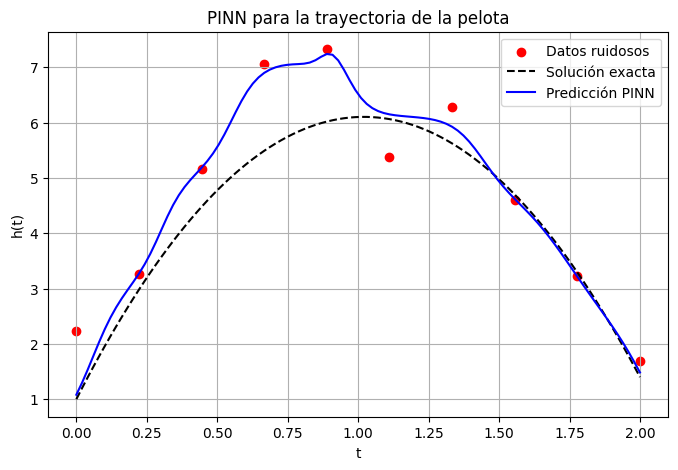

In [ ]:
# ============================================
# 7. EVALUACIÓN DEL MODELO ENTRENADO
# ============================================

model.eval()

t_plot = np.linspace(t_min, t_max, 100).reshape(-1, 1).astype(np.float32)
t_plot_tensor = torch.tensor(t_plot, requires_grad=True)
h_pred_plot = model(t_plot_tensor).detach().numpy()

# Solución exacta
h_true_plot = true_solution(t_plot)

# Gráfica
plt.figure(figsize=(8, 5))
plt.scatter(t_data, h_data_noisy, color='red', label='Datos ruidosos')
plt.plot(t_plot, h_true_plot, 'k--', label='Solución exacta')
plt.plot(t_plot, h_pred_plot, 'b', label='Predicción PINN')
plt.xlabel('t')
plt.ylabel('h(t)')
plt.legend()
plt.title('PINN para la trayectoria de la pelota')
plt.grid(True)
plt.show()
